<a href="https://colab.research.google.com/github/branGitfox/APK-MGstore/blob/master/machine_learning_Brandon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bibliothèques importées avec succès
Dimensions du dataset : 20640 lignes × 9 colonnes

Variable cible : MedHouseVal (valeur médiane du logement en centaines de milliers de $)

Description des variables :
------------------------------------------------------------
 MedInc          → Revenu médian du quartier
 HouseAge        → Âge médian des logements
 AveRooms        → Nombre moyen de pièces par logement
 AveBedrms       → Nombre moyen de chambres par logement
 Population      → Population du quartier
 AveOccup        → Nombre moyen d'occupants par logement
 Latitude        → Latitude géographique
 Longitude       → Longitude géographique
 MedHouseVal     → Prix médian du logement (cible)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85 

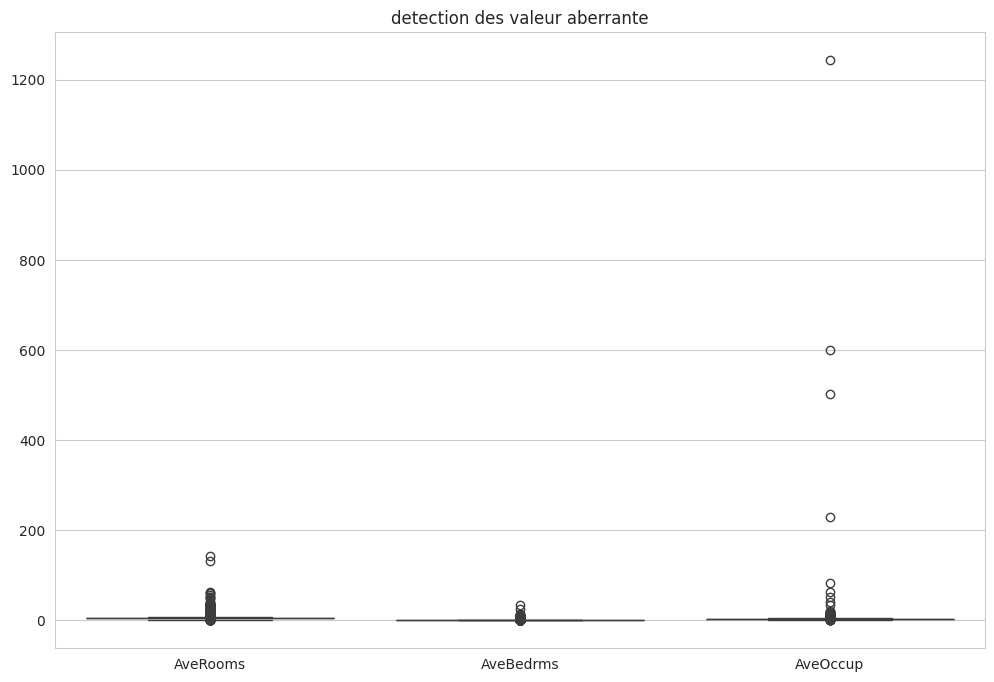

       AveBedrms   AveOccup   AveRooms
2511    3.500000  14.000000  24.500000
10077   4.740000   3.370000  19.860000
13943   4.096429   3.139286  28.432143
13945   3.169935   3.010893  20.520697


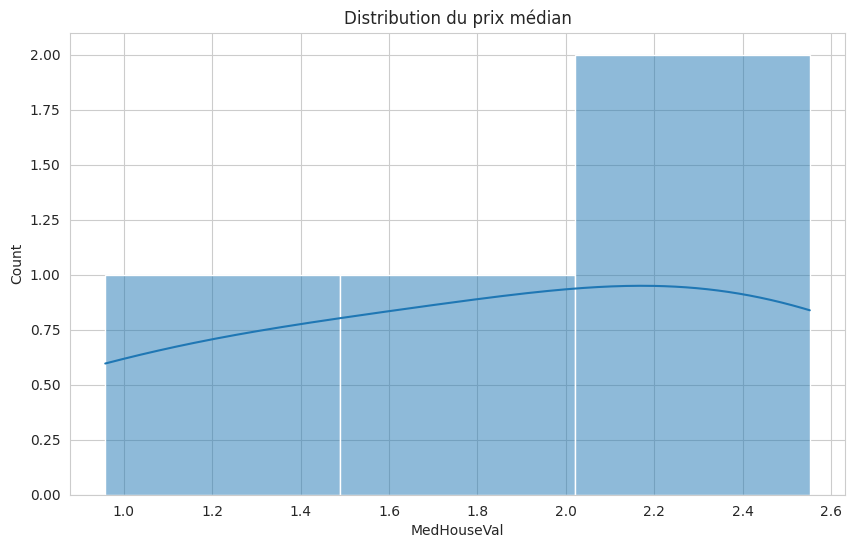

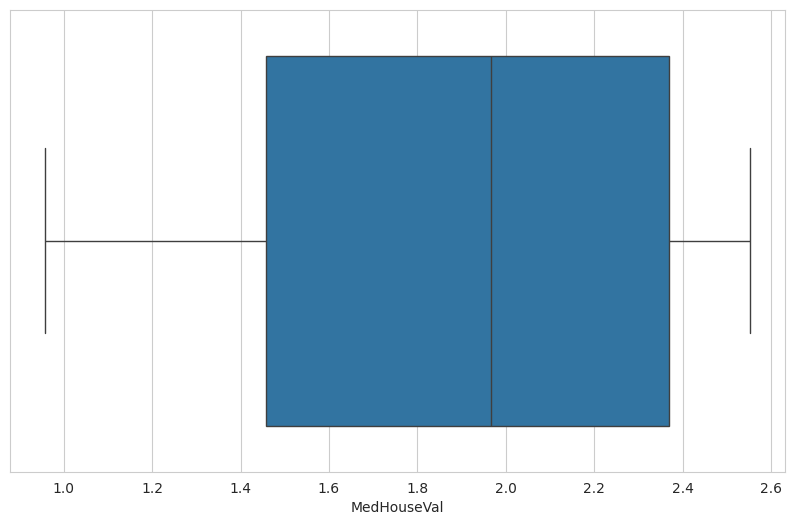

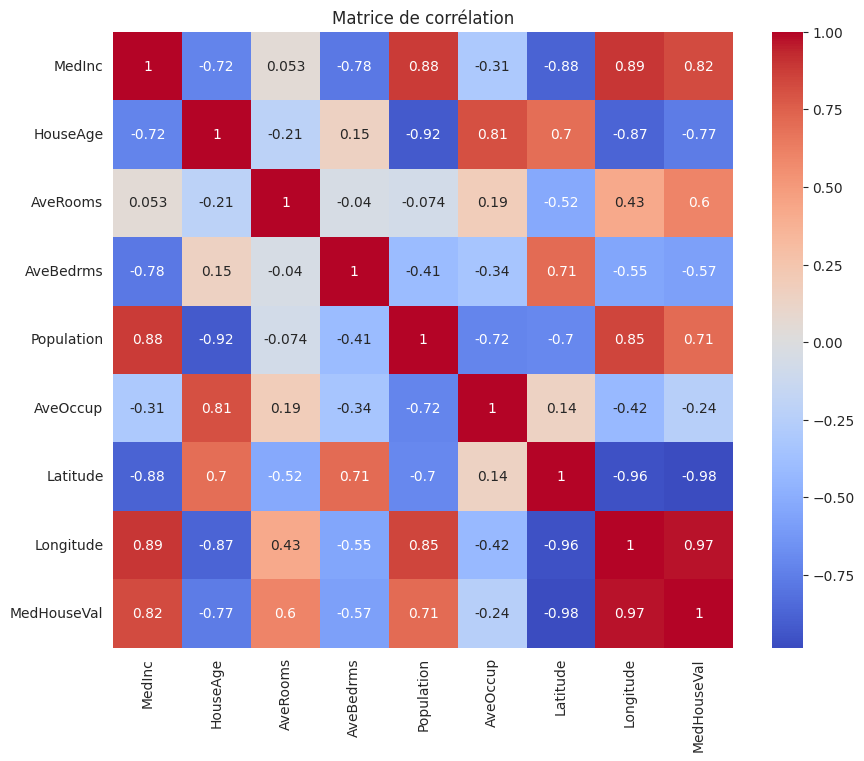

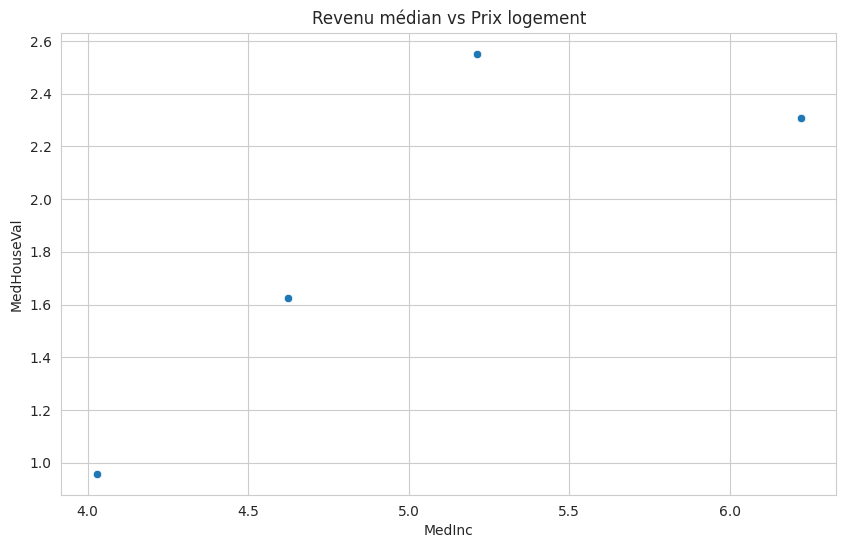

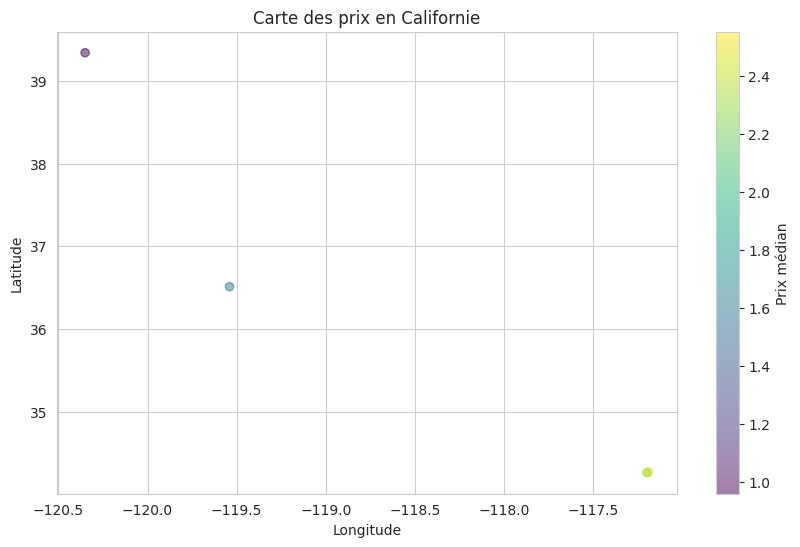

Intercept β0 : 2.2667960106691125

Coefficients :                   Coefficient
MedInc              -0.001018
HouseAge            -0.020037
AveRooms             0.015896
AveBedrms            0.001987
Population           0.007085
AveOccup            -0.009840
Latitude            -0.002055
Longitude            0.002188
PiecesParChambre     0.000669
PopParLogement      -0.020441
MSE  : 1.0357182647838068
RMSE : 1.0177024441278535
MAE  : 1.0177024441278535
R²   : nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


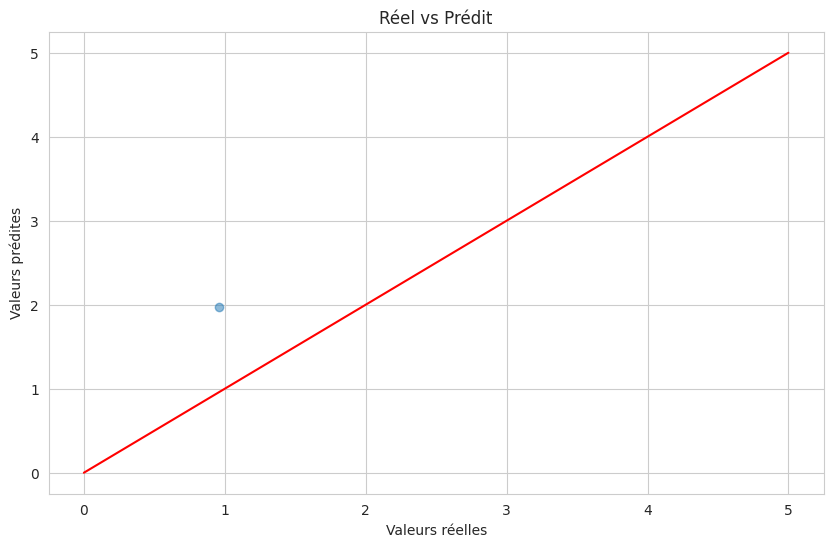

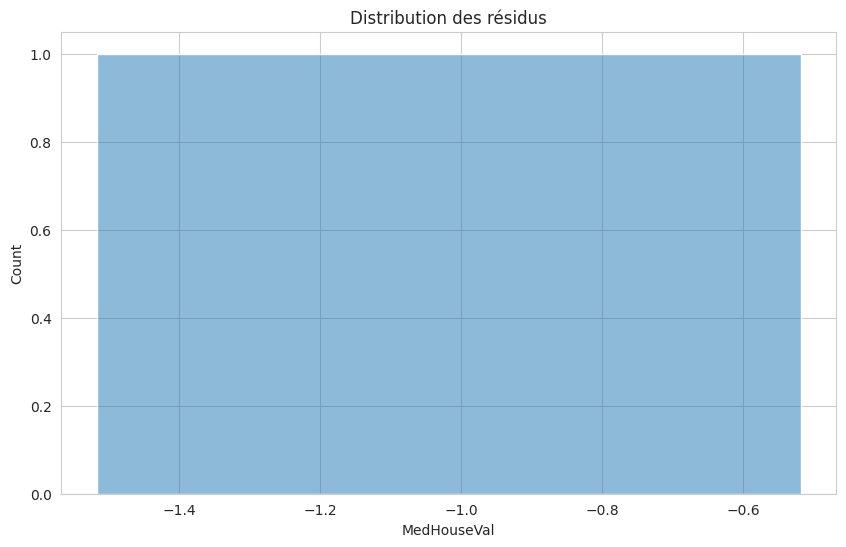

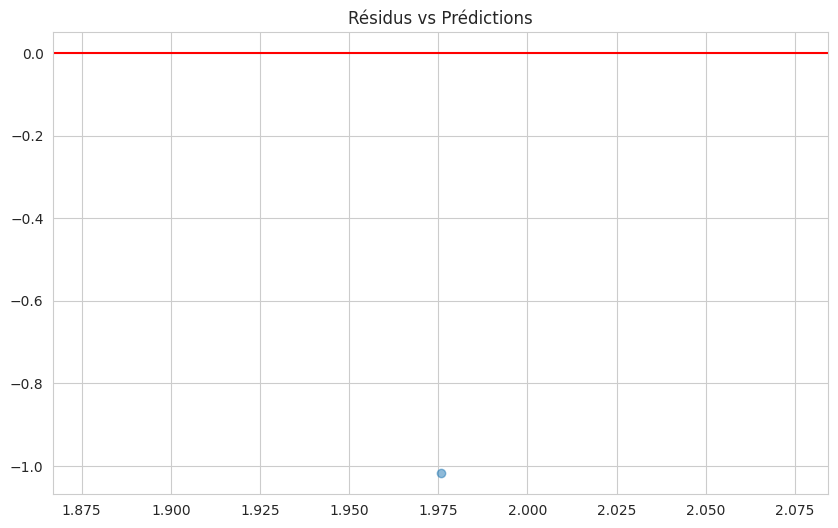

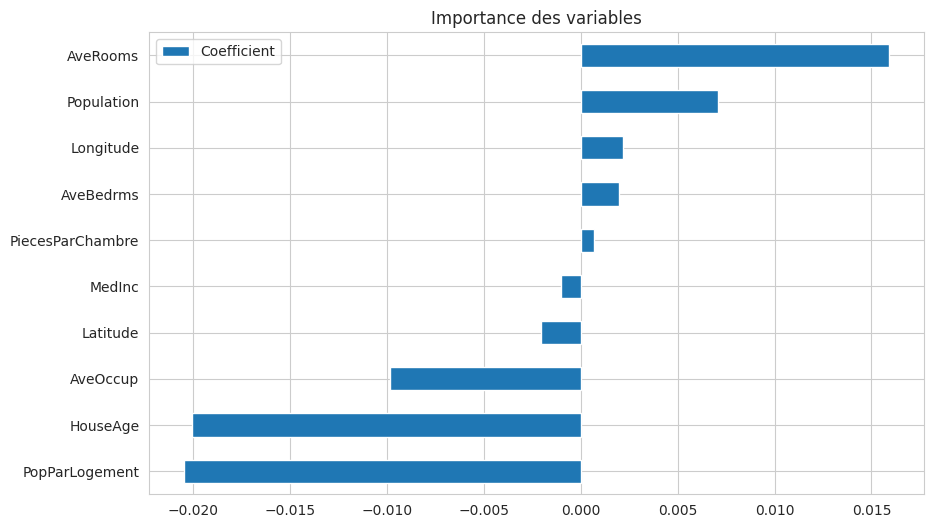

In [ ]:
"""

Informations sur l'etudiant

Nom: Ravomnanana
Prenom: Brandon Fidelin
Filiere: IGGLIA 4

"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#1. Chargement et inspection des données
# Configuration graphique
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Bibliothèques importées avec succès")
# Charger le jeu de données California Housing
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print(f"Dimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nVariable cible : MedHouseVal (valeur médiane du logement en centaines de milliers de $)")
print(f"\nDescription des variables :")
print("-" * 60)
descriptions = {
    'MedInc': 'Revenu médian du quartier',
    'HouseAge': 'Âge médian des logements',
    'AveRooms': 'Nombre moyen de pièces par logement',
    'AveBedrms': 'Nombre moyen de chambres par logement',
    'Population': 'Population du quartier',
    'AveOccup': 'Nombre moyen d\'occupants par logement',
    'Latitude': 'Latitude géographique',
    'Longitude': 'Longitude géographique',
    'MedHouseVal': 'Prix médian du logement (cible)'
}
for col, desc in descriptions.items():
    print(f" {col:15s} → {desc}")
# Afficher les premières lignes avec .head()
print(df.head())
# pour avoir un aperçu visuel des données
# Utiliser .info() pour vérifier les types de colonnes
# et détecter les éventuelles valeurs manquantes
print(df.info())
    # Utiliser .describe() pour obtenir les statistiques descriptives :
    # moyenne, écart-type, min, max, quartiles de chaque colonne
print(df.describe())

#2. Nettoyage des données

# Vérifier les valeurs manquantes avec .isnull().sum()
print(df.isnull().sum())
# Si présentes : soit les supprimer (.dropna), soit les imputer (.fillna)
# Vérifier et supprimer les doublons avec .duplicated() et .drop_duplicates()
if df.duplicated().any():
    df.drop_duplicates(inplace=True)
# Détecter les valeurs aberrantes (outliers) à l'aide de boxplots
# Les boxplots montrent visuellement la distribution et les points extrêmes
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[["AveRooms", "AveBedrms", "AveOccup"]])
plt.title("detection des valeur aberrante")
plt.show()
# Filtrer les outliers extrêmes pour AveRooms, AveBedrms et AveOccup
# On fixe des seuils raisonnables (ex: AveRooms < 50, AveOccup < 20)
# pour éviter que ces valeurs extrêmes faussent le modèle
df = df[df["AveBedrms"] > 3]
df = df[df["AveOccup"] > 3]
df = df[df["AveRooms"] > 10]
print(df[["AveBedrms","AveOccup","AveRooms"]].head())

#3. Analyse exploratoire (EDA)
# Tracer la distribution de la variable cible (MedHouseVal)
# avec un histogramme + courbe de densité (kde)
# et un boxplot pour repérer la médiane et les extrêmes
# Calculer et afficher la matrice de corrélation sous forme de heatmap
# Cela permet d'identifier quelles variables sont le plus liées au prix :
# - corrélation proche de +1 → relation positive forte
# - corrélation proche de -1 → relation négative forte
# - corrélation proche de 0 → pas de relation linéaire
# Scatter plots : croiser les variables les plus corrélées avec la cible
# Ex : MedInc vs MedHouseVal → on s'attend à une relation positive forte
# (plus le revenu est élevé, plus le logement est cher)
# Carte géographique : afficher chaque quartier (Latitude, Longitude)
# coloré selon le prix médian, pour visualiser la répartition spatiale
# des prix en Californie (zones côtières = plus cher)
sns.histplot(df['MedHouseVal'], kde=True)
plt.title("Distribution du prix médian")
plt.show()

sns.boxplot(x=df['MedHouseVal'])
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

sns.scatterplot(x=df['MedInc'], y=df['MedHouseVal'])
plt.title("Revenu médian vs Prix logement")
plt.show()

plt.scatter(df['Longitude'], df['Latitude'],
            c=df['MedHouseVal'], cmap='viridis', alpha=0.5)
plt.colorbar(label="Prix médian")
plt.title("Carte des prix en Californie")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

#4. Ingénierie des variables
# Créer de nouvelles variables dérivées, par exemple :
# PiecesParChambre = AveRooms / AveBedrms (ratio pièces/chambres)
# PopParLogement = Population / AveOccup (estimation du nb de logements)
df['PiecesParChambre'] = df['AveRooms'] / df['AveBedrms']
df['PopParLogement'] = df['Population'] / df['AveOccup']

# Ces nouvelles features peuvent capturer des informations supplémentaires
# Séparer les données en :
# X = variables explicatives (features) → les 10 colonnes d'entrée
# y = variable cible → MedHouseVal (le prix à prédire)
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

#5. Séparation entraînement / test
# Diviser X et y en deux sous-ensembles avec train_test_split :
# - 80% pour l'entraînement (le modèle apprend sur ces données)
# - 20% pour le test (on évalue la qualité des prédictions)
# Le paramètre random_state=42 garantit la reproductibilité
# Le modèle cherche à trouver la relation :
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  6. Construction du modèle de régression linéaire
# où est l'ordonnée à l'origine et sont les coefficients de chaque variable.
# y^ = β0 + β1x1 + β2x2 + ⋯ + βnxn
# β0 βi
# Instancier LinearRegression() et entraîner avec .fit(X_train, y_train)
# Le modèle calcule les coefficients β optimaux en minimisant
# la somme des carrés des erreurs (méthode des moindres carrés)
# Afficher :
# - model.intercept_ → l'ordonnée à l'origine (β₀)
# - model.coef_ → les coefficients (β₁, β₂, ..., βₙ)
# Un coefficient positif = la variable augmente le prix
# Un coefficient négatif = la variable diminue le prix
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept β0 :", model.intercept_)
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print("\nCoefficients :",coeff_df)

#7. Prédiction et évaluation
# Prédire les prix sur l'ensemble de test avec model.predict(X_test)
# Puis calculer les métriques d'évaluation :
#
# MSE = moyenne des (réel - prédit)² → erreur quadratique moyenne
# RMSE = √MSE → plus interprétable (même unité que y)
# MAE = moyenne des |réel - prédit| → erreur absolue moyenne
# R² = 1 - (SS_res / SS_tot) → proportion de variance expliquée
#
# R² = 1.0 → prédiction parfaite
# R² = 0.0 → le modèle ne fait pas mieux que la moyenne
y_pred = model.predict(X_test)

MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y_test, y_pred)
R2 = r2_score(y_test, y_pred)

print("MSE  :", MSE)
print("RMSE :", RMSE)
print("MAE  :", MAE)
print("R²   :", R2)

#8. Visualisation des résultats
# Graphique 1 : Valeurs réelles vs Prédites
# Un scatter plot avec la ligne diagonale (prédiction parfaite)
# Plus les points sont proches de la diagonale, meilleur est le modèle
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0,5],[0,5],'r')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Réel vs Prédit")
plt.show()
# Graphique 2 : Analyse des résidus (résidu = réel - prédit)
# a) Histogramme des résidus → devrait suivre une distribution normale centrée sur 0
residus = y_test - y_pred

sns.histplot(residus, kde=True)
plt.title("Distribution des résidus")
plt.show()

# b) Résidus vs Prédictions → les points doivent être dispersés aléatoirement
# (un pattern visible indiquerait que le modèle rate quelque chose)
plt.scatter(y_pred, residus, alpha=0.5)
plt.axhline(0, color='r')
plt.title("Résidus vs Prédictions")
plt.show()

# Graphique 3 : Barplot des coefficients du modèle
# Permet de visualiser l'importance relative de chaque variable :
#  Coefficient positif = contribue à augmenter le prix
#  Coefficient négatif = contribue à diminuer le prix
coeff_df.sort_values("Coefficient").plot(kind="barh")
plt.title("Importance des variables")
plt.show()


#9. Export des résultats
# Créer un DataFrame de résultats contenant :
# - les features du test
# - le prix réel
# - le prix prédit
# - le résidu (écart)
# - l'erreur en pourcentage
# Puis exporter en CSV avec .to_csv("resultats_regression.csv")
resultats = X_test.copy()
resultats["Prix_reel"] = y_test
resultats["Prix_predit"] = y_pred
resultats["Residus"] = y_test - y_pred
resultats["Erreur_%"] = abs(resultats["Residus"]/resultats["Prix_reel"])*100

resultats.to_csv("resultats_regression.csv", index=False)